### **Reducción de paradas no programadas mediante análisis predictivo en mantenimiento industrial**

---



Este proyecto consiste en un estudio de caso detallado sobre mantenimiento predictivo utilizando un conjunto de datos de manufactura. El objetivo principal es identificar patrones de falla en maquinaria industrial para transformar una estrategia de mantenimiento reactiva en una proactiva y basada en datos.

A través del análisis de variables térmicas y mecánicas, se identifican los factores críticos que preceden a las paradas no programadas, proponiendo soluciones que optimizan la disponibilidad de los equipos y reducen costos operativos.

# Tecnologías Utilizadas

**Python**: Lenguaje principal para el procesamiento.

**Pandas & NumPy**: Limpieza y manipulación de datos.

**Matplotlib & Seaborn**: Visualización de datos y análisis estadístico.

**Jupyter Notebooks**: Documentación del proceso paso a paso.

Importación de librerías para trabajar

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Importación de archivo de datos (en formato .csv)

In [2]:
df = pd.read_csv('predictive_maintenance.csv')

Mediante este código, se obtiene información de cantidad de columnas, si posee valores nulos y tipo de dato

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


Obtenemos una descripción puramente estadística indicandonos la media, estándar, mínima y rango intercuartílico de las diferentes variables

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


Ahora obtenemos las primeras filas y columnas del archivo de datos. comenzamos con la limpieza

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


Creo un código para simplificar los nombres de las columnas

In [6]:
df.columns = [
    'ID', 'product_id', 'type', 'air_temp', 'process_temp',
    'RPM', 'torque', 'tool_wear', 'target', 'failure_type'
]

Realizo una conversión de medidas de temperatura, ya que los datos originalmente están en Kelvin (K).
Serán transformados a Celsius.

In [7]:
df['air_temp'] = df['air_temp'] - 273.15
df['process_temp'] = df['process_temp'] - 273.15

In [8]:
df.head()

,ID,product_id,type,air_temp,process_temp,RPM,torque,tool_wear,target,failure_type
0,1,M14860,M,24.95,35.45,1551,42.8,0,0,No Failure
1,2,L47181,L,25.05,35.55,1408,46.3,3,0,No Failure
2,3,L47182,L,24.95,35.35,1498,49.4,5,0,No Failure
3,4,L47183,L,25.05,35.45,1433,39.5,7,0,No Failure
4,5,L47184,L,25.05,35.55,1408,40.0,9,0,No Failure


Ahora, quiero verificar inconsistencias entre las filas **target** y **failure_type**. La columna target indica si hubo falla (1) o no (0). Debo asegurarme de que cuando target sea 0, el failure_type sea realmente "No Failure".

In [9]:
inconsistencias = df[(df['target'] == 0) & (df['failure_type'] != 'No Failure')]
print(f"Filas inconsistentes: {len(inconsistencias)}")

Filas inconsistentes: 18


Búsqueda positiva. se hallaron 18 inconsistencias, por lo tanto, se procede a limpiarlas.

In [10]:
df = df.drop(inconsistencias.index)

**GRÁFICO 1**: Distribución de fallas por tipo de producto (L, M, H)
 Esto ayuda a ver si los productos de baja calidad (L) fallan más que los de alta (H)

/tmp/ipykernel_9411/1303119129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['target'] == 1], x='type', palette='viridis')


Text(0, 0.5, 'Cantidad de Fallas')

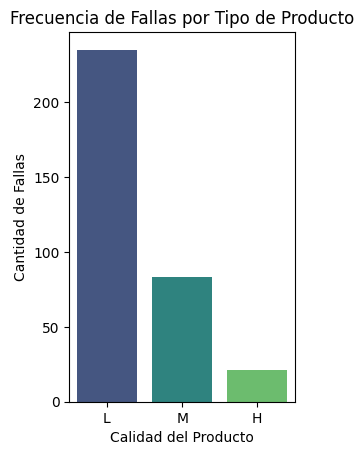

In [11]:
plt.subplot(1, 2, 1)
sns.countplot(data=df[df['target'] == 1], x='type', palette='viridis')
plt.title('Frecuencia de Fallas por Tipo de Producto')
plt.xlabel('Calidad del Producto')
plt.ylabel('Cantidad de Fallas')

**El impacto de la calidad**

---


El gráfico de barras muestra que el tipo **L** (Low) tiene muchas más fallas que el **H** (High)¿cuál es la conclusión en este caso?
Se recomienda revisar los estándares de los materiales de baja calidad, ya que representan el un porcentaje posiblemente significativo de las paradas no programadas.

**GRÁFICO 2**: Relación entre Torque y RPM (Análisis de ingeniería)
Es vital para ver cómo operan las máquinas antes de fallar.

Text(0.5, 1.0, 'Relación RPM vs Torque (Fallas en Rojo)')

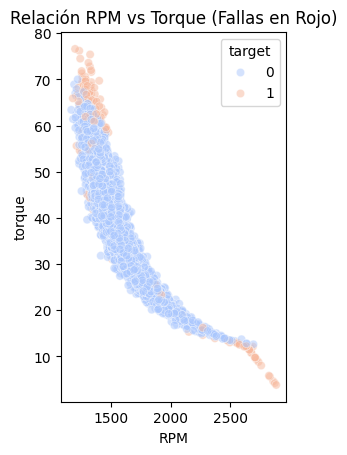

In [12]:
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='RPM', y='torque', hue='target', alpha=0.5, palette='coolwarm')
plt.title('Relación RPM vs Torque (Fallas en Rojo)')

**La relación inversa**

---

En el gráfico de dispersión, se aprecia una curva perfecta. En física industrial, si las RPM suben, el Torque baja. Los puntos rojos (fallas) que se salen de esa curva son "anomalías" que deberán investigarse.

Analizar el desgaste de la herramienta es clave, porque es una variable acumulativa. En una planta, esto te diría cada cuánto tiempo deberías programar un cambio de pieza antes de que se rompa.

/tmp/ipykernel_9411/3854548707.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='tool_wear', palette='Set2', ax=ax2)
/tmp/ipykernel_9411/3854548707.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Normal', 'Falla'])


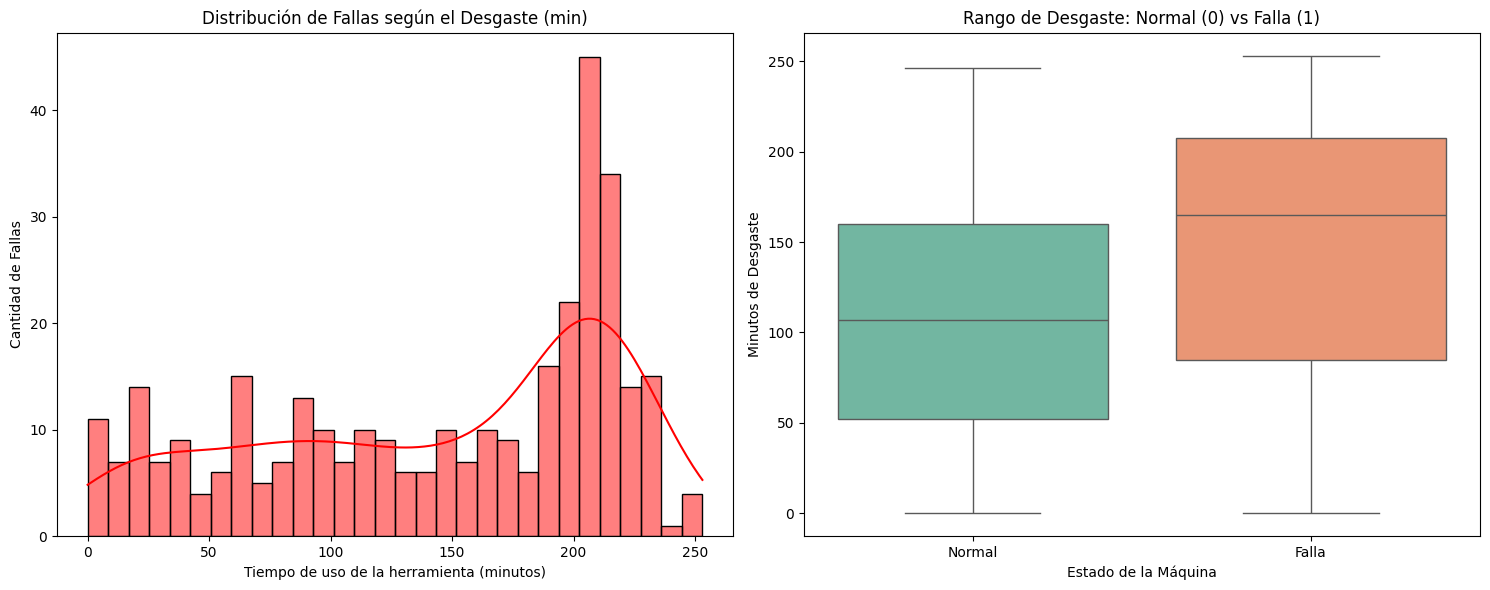

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(data=df[df['target'] == 1], x='tool_wear', bins=30, kde=True, color='red', ax=ax1)
ax1.set_title('Distribución de Fallas según el Desgaste (min)')
ax1.set_xlabel('Tiempo de uso de la herramienta (minutos)')
ax1.set_ylabel('Cantidad de Fallas')
sns.boxplot(data=df, x='target', y='tool_wear', palette='Set2', ax=ax2)
ax2.set_title('Rango de Desgaste: Normal (0) vs Falla (1)')
ax2.set_xticklabels(['Normal', 'Falla'])
ax2.set_xlabel('Estado de la Máquina')
ax2.set_ylabel('Minutos de Desgaste')

plt.tight_layout()
plt.show()

1. **HISTOGRAMA**: ¿En qué minuto de desgaste ocurren más fallas?
Conclusión: El riesgo de falla aumenta drásticamente después de los 180 minutos, sugiriendo un reemplazo preventivo en el minuto 150.
2. **BOXPLOT**: Comparativa visual entre Operación Normal vs Falla.
conclusión: Se confirma que el desgaste es un factor determinante.

Basado en mi experiencia en planta, el análisis de herramental permite pasar de un modelo de mantenimiento reactivo (reparar cuando se rompe) a uno preventivo, optimizando los tiempos de parada de línea.

## **Conclusión Técnica**

---



# Resumen del Análisis

El análisis reveló patrones críticos que permiten anticipar paradas no programadas:

**Umbral de Desgaste**: Se identificó que la probabilidad de falla aumenta exponencialmente después de los 180-200 minutos de uso de la herramienta (tool_wear).

**Correlación Operativa**: Las fallas de tipo Power Failure están estrechamente ligadas a una caída en las RPM por debajo de un umbral específico cuando el Torque supera los 60 Nm.

**Factor de Calidad**: Los productos de tipo L (Low) presentan una frecuencia de falla mayor, lo que sugiere que la intensidad del proceso impacta más en equipos con materiales de menor grado.






# Impacto en el Negocio
Implementar un sistema de alertas basado en estos hallazgos permitiría:

**Reducir el mantenimiento correctivo**: Reemplazando herramientas en el minuto 180 de forma programada.

**Ahorro de costos**: Evitar el desperdicio de materia prima (scrap) causado por fallas súbitas durante el ciclo de producción.

**Monitoreo en Tiempo Real**: Establecer sensores de control sobre la relación Torque/RPM para detener la máquina antes de que ocurra una sobrecarga (Overstrain).